In [2]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import AutoTokenizer, AutoModel
import torch.nn as nn
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc
from peft import LoraConfig, get_peft_model  # For efficient fine-tuning



In [2]:
df = pd.read_excel('bioactivity_dataset_cleaned_new.xlsx')
# df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)
# df = df.dropna(subset=['mol'])

# # Compute/scale descriptors (if not already)
# def compute_descriptors(smiles):
#     mol = Chem.MolFromSmiles(smiles)
#     if mol is None: return np.zeros(4)
#     return np.array([Descriptors.MolWt(mol),
#                 Descriptors.MolLogP(mol),
#                 Descriptors.TPSA(mol),
#                 Descriptors.NumHDonors(mol),
#                 Descriptors.NumHAcceptors(mol),
#                 Descriptors.NumRotatableBonds(mol),
#                 Descriptors.NumAromaticRings(mol),
#                 Descriptors.FractionCSP3(mol)])

# df[['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']] = df['canonical_smiles'].apply(compute_descriptors).tolist()

# # scaler = StandardScaler()
# desc_cols = ['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']
# df[desc_cols] = scaler.fit_transform(df[desc_cols])

In [3]:
df = pd.read_excel('bioactivity_dataset_cleaned_new.xlsx')
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,FractionCSP3,RingCount,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,129.65,11,0.280000,3,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,133.31,10,0.222222,4,1
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,107.53,7,0.041667,3,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6341 entries, 0 to 6340
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   6341 non-null   object 
 1   MW                 6341 non-null   float64
 2   LogP               6341 non-null   float64
 3   NumHDonors         6341 non-null   int64  
 4   TPSA               6341 non-null   float64
 5   NumRotatableBonds  6341 non-null   int64  
 6   FractionCSP3       6341 non-null   float64
 7   RingCount          6341 non-null   int64  
 8   bioactivity        6341 non-null   int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 446.0+ KB


In [4]:
df.iloc[0]['canonical_smiles']

'O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc12)NO'

In [5]:
df['bioactivity'].value_counts()

bioactivity
1    5118
0    1223
Name: count, dtype: int64

In [5]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_recall_curve
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# CONFIG (Fixed)
# -------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 512
BATCH_SIZE = 32
ECFP_BITS = 1024
ECFP_RADIUS = 2
AUGMENT_TRAIN = True


train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['bioactivity'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

scaler=StandardScaler().fit(train_df[['MW', 'LogP', 'NumHDonors', 'TPSA', 'NumRotatableBonds', 'FractionCSP3', 'RingCount']])

# -------------------------------
# SMILES Augmentation
# -------------------------------
def random_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return smiles
    return Chem.MolToSmiles(mol, doRandom=True, canonical=False)

# -------------------------------
# ECFP Generator
# -------------------------------
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=ECFP_RADIUS, fpSize=ECFP_BITS)
def get_ecfp(smiles, radius=ECFP_RADIUS, n_bits=ECFP_BITS):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits, dtype=np.float32)
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# -------------------------------
# Dataset
# -------------------------------

tokenizer = AutoTokenizer.from_pretrained('ibm/MoLFormer-XL-both-10pct', trust_remote_code=True)

class BioActivityDataset(Dataset):
    def __init__(self, df, tokenizer, scaler=None, ecfp_cache=None, augment=False):
        self.smiles = df['canonical_smiles'].values.tolist()
        self.desc   = df[['MW', 'LogP', 'NumHDonors', 'TPSA', 'NumRotatableBonds', 'FractionCSP3', 'RingCount']].values.astype(np.float32)
        self.labels = df['bioactivity'].values.astype(np.float32)
        self.encodings = tokenizer(self.smiles, truncation=True, padding=True, max_length=512, return_tensors='pt')
        self.augment = augment
        self.max_len = MAX_LEN

        
        if scaler is None:
            self.scaler = StandardScaler().fit(self.desc)
        else:
            self.scaler = scaler
        self.desc = self.scaler.transform(self.desc)
        
        print("Computing ECFP...")
        self.ecfp = np.stack([get_ecfp(s) for s in self.smiles])
        

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx): 
        item = {k: v[idx] for k, v in self.encodings.items()}

        item['ecfp']=torch.tensor(self.ecfp[idx])
        item['descriptors']=torch.tensor(self.desc[idx])
        item['labels']=torch.tensor(self.labels[idx])

        return item

# -------------------------------
# Collate Function
# -------------------------------
def collate_fn(batch):
    return {
        'input_ids': torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'descriptors': torch.stack([b['descriptors'] for b in batch]),
        'ecfp': torch.stack([b['ecfp'] for b in batch]),
        'labels': torch.tensor([b['labels'] for b in batch], dtype=torch.float)
    }



In [12]:
# from imblearn.combine import SMOTETomek
# from imblearn.over_sampling import SMOTENC


# train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['bioactivity'], random_state=42)
# val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# tokenizer = AutoTokenizer.from_pretrained('ibm/MoLFormer-XL-both-10pct', trust_remote_code=True)
# #tokenizer = AutoTokenizer.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')

# class BioactivityDataset(Dataset):
#     def __init__(self, df, tokenizer, desc_scaler):
#         self.smiles = df['canonical_smiles'].tolist()
#         self.labels = df['bioactivity'].tolist()
#         self.descs = df[desc_cols].values
#         #self.desc_scaler = desc_scaler
#         self.encodings = tokenizer(self.smiles, truncation=True, padding=True, max_length=512, return_tensors='pt')
    
#     def __len__(self): return len(self.labels)
#     def __getitem__(self, idx):
#         item = {k: v[idx] for k, v in self.encodings.items()}
#         item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
#         item['descriptors'] = torch.tensor(self.descs[idx], dtype=torch.float)
#         return item

In [ ]:
# train_dataset = BioActivityDataset(train_df, tokenizer, scaler=scaler)
# val_dataset = BioActivityDataset(val_df, tokenizer, scaler=scaler)
# test_dataset = BioActivityDataset(test_df, tokenizer, scaler=scaler)
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=32)
# test_loader = DataLoader(test_dataset, batch_size=32)

In [6]:
train_df['bioactivity'].value_counts(), val_df['bioactivity'].value_counts(), test_df['bioactivity'].value_counts()

(bioactivity
 1    3582
 0     856
 Name: count, dtype: int64,
 bioactivity
 1    764
 0    187
 Name: count, dtype: int64,
 bioactivity
 1    772
 0    180
 Name: count, dtype: int64)

#### ECFP + BERT embedding based model

In [7]:
# -------------------------------
# Model
# -------------------------------
class FineTunedBERTaECFP(nn.Module):
    def __init__(self, ecfp_bits=ECFP_BITS, unfreeze_layers=12, num_heads=8, 
                 dropout=0.3, hidden_dim=768, num_classifier_layers=4, 
                 fusion_type='gated'):
        super().__init__()
        self.bert = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

        # Unfreeze last N layers
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-unfreeze_layers:]:
            for p in layer.parameters():
                p.requires_grad = True

        # Project ECFP and descriptors to 768
        self.ecfp_proj = nn.Sequential(
            nn.Linear(ecfp_bits, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 768),
            nn.LayerNorm(768),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.desc_proj = nn.Sequential(
            nn.Linear(7, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 768),
            nn.LayerNorm(768),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Attention
        self.attn = nn.MultiheadAttention(768, num_heads=num_heads, batch_first=True, dropout=dropout*0.5)
        self.attn_norm = nn.LayerNorm(768)

        self.fusion_type = fusion_type
        if fusion_type == 'gated':
            self.gate = nn.Sequential(
                nn.Linear(768 * 3, 768),
                nn.Sigmoid()
            )
            self.fusion_proj = nn.Linear(768 * 3, 768)
        elif fusion_type == 'bilinear':
            self.bilinear = nn.Bilinear(768, 768, 768)

        # Classifier
        classifier_layers = []
        in_dim = 768 * 3 if fusion_type == 'concat' else 768
        
        for i in range(num_classifier_layers):
            out_dim = hidden_dim // (2 ** i)
            classifier_layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.LayerNorm(out_dim),
                nn.GELU(),
                nn.Dropout(dropout if i < num_classifier_layers - 1 else dropout * 0.5)
            ])
            in_dim = out_dim
        
        classifier_layers.append(nn.Linear(in_dim, 1))
        self.classifier = nn.Sequential(*classifier_layers)
        # self.classifier = nn.Sequential(
        #     nn.Linear(768 * 3, hidden_dim),
        #     nn.LayerNorm(hidden_dim),
        #     nn.GELU(),
        #     nn.Dropout(dropout),
        #     nn.Linear(hidden_dim, hidden_dim//2),
        #     nn.LayerNorm(hidden_dim//2),
        #     nn.GELU(),
        #     nn.Dropout(dropout),
        #     nn.Linear(hidden_dim//2, hidden_dim//4),
        #     nn.GELU(),
        #     nn.Dropout(dropout/2),
        #     nn.Linear(hidden_dim // 4, 1)
        # )


    def forward(self, input_ids, attention_mask, ecfp, descriptors):
        # SMILES
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        cls_ = out.last_hidden_state[:,0]
        mean_pool = out.last_hidden_state.mean(dim=1)  # [B,768]
        max_pool = out.last_hidden_state.max(dim=1)[0]
        smiles = (cls_ + mean_pool + max_pool) / 3

        # ECFP + Desc
        #ecfp_emb = self.ecfp_proj(ecfp)             # [B,768]
        desc_emb = self.desc_proj(descriptors)      # [B,768]

        # Attention
        #q = torch.stack([ecfp_emb, desc_emb], dim=1)  # [B,2,768]
        kv = smiles.unsqueeze(1)                       # [B,1,768]
        attn_out, attn_weights = self.attn(desc_emb.unsqueeze(1), kv, kv)             # [B,2,768]

        desc_attn = self.attn_norm(attn_out[:,0] + desc_emb)    # [B,768]
        #desc_attn = self.attn_norm(attn_out[:,1] + desc_emb)   # [B,768]

        # Fuse
        if self.fusion_type == 'concat':
            fused = torch.cat([smiles, desc_attn], dim=1)
        elif self.fusion_type == 'gated':
            concat = torch.cat([smiles, desc_attn], dim=1)
            gate = self.gate(concat)
            fused = gate * self.fusion_proj(concat)
        else:  # bilinear
            fused = self.bilinear(smiles, desc_attn)
        
        return self.classifier(fused).squeeze(-1)

model = FineTunedBERTaECFP(unfreeze_layers=12, num_heads=8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

FineTunedBERTaECFP(
  (bert): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (d

#### test

In [36]:
# -------------------------------
# Training Function (for Optuna)
# -------------------------------
def train_and_evaluate(trial):
    # --- Suggest Hyperparameters ---
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    lr = trial.suggest_loguniform('lr', 1e-5, 5e-5)
    dropout = trial.suggest_uniform('dropout', 0.3, 0.6)
    num_heads = trial.suggest_categorical('num_heads', [4, 8, 12])
    hidden_dim = trial.suggest_categorical('hidden_dim', [256, 512, 768])
    unfreeze_layers = trial.suggest_int('unfreeze_layers', 6, 12)
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-3, 1e-1)

    # --- Data Loaders ---
    tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

    train_ds = BioActivityDataset(train_df, tokenizer, augment=AUGMENT_TRAIN, ecfp_cache='train_ecfp.npy')
    val_ds   = BioActivityDataset(val_df, tokenizer, scaler=train_ds.scaler, ecfp_cache='val_ecfp.npy')
    test_ds  = BioActivityDataset(test_df, tokenizer, scaler=train_ds.scaler, ecfp_cache='test_ecfp.npy')

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers=4)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=4)

    # --- Model ---
    model = ChemBERTaECFP(unfreeze_layers=unfreeze_layers, num_heads=num_heads, dropout=dropout, hidden_dim=hidden_dim).to(DEVICE)

    # --- Loss ---
    pos_weight = torch.tensor([len(train_ds) - sum(train_ds.labels)] / sum(train_ds.labels)).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # --- Optimizer + Scheduler ---
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * EPOCHS
    warmup_steps = int(0.1 * total_steps)
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: min(step/warmup_steps, 1) * \
                               (0.5 * (1 + np.cos(np.pi * step / total_steps)))
    )

    # --- Training Loop ---
    best_auc = 0.0
    patience_counter = 0
    for epoch in range(EPOCHS):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            logits = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                descriptors=batch['descriptors'].to(DEVICE),
                ecfp=batch['ecfp'].to(DEVICE)
            )
            loss = criterion(logits, batch['labels'].to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            scheduler.step()

        # Validation
        model.eval()
        val_probs, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                logits = model(
                    batch['input_ids'].to(DEVICE),
                    batch['attention_mask'].to(DEVICE),
                    descriptors=batch['descriptors'].to(DEVICE),
                    ecfp=batch['ecfp'].to(DEVICE)
                )
                probs = torch.sigmoid(logits).cpu().numpy()
                val_probs.extend(probs)
                val_labels.extend(batch['labels'].numpy())

        auc = roc_auc_score(val_labels, val_probs)

        if auc > best_auc + 1e-4:
            best_auc = auc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    return best_auc  # Optuna maximizes this

# -------------------------------
# Optuna Study
# -------------------------------
if __name__ == "__main__":
    # REPLACE WITH YOUR DATAFRAMES: train_df, val_df, test_df
    # Assumes they are loaded (e.g., via pd.read_csv)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
    study.optimize(train_and_evaluate, n_trials=50)  # Run 50 trials

    print("Best hyperparameters:", study.best_params)
    print("Best val AUROC:", study.best_value)

    # --- Retrain with best params and evaluate on test ---
    # (Implement similar to train_and_evaluate, but use study.best_params and run on test)

[I 2025-11-15 09:30:04,052] A new study created in memory with name: no-name-63c87fb7-f8ce-48d6-acc5-18f09e8afe09


Computing ECFP...
Computing ECFP...
Computing ECFP...


[W 2025-11-15 09:30:10,994] Trial 0 failed with parameters: {'batch_size': 16, 'lr': 1.0735469844155669e-05, 'dropout': 0.4404369505553404, 'num_heads': 8, 'hidden_dim': 512, 'unfreeze_layers': 7, 'weight_decay': 0.0077893966911560504} because of the following error: NameError("name 'ChemBERTaECFP' is not defined").
Traceback (most recent call last):
  File "e:\ML\BioActivity\.venv\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\era\AppData\Local\Temp\ipykernel_21756\150824060.py", line 25, in train_and_evaluate
    model = ChemBERTaECFP(unfreeze_layers=unfreeze_layers, num_heads=num_heads, dropout=dropout, hidden_dim=hidden_dim).to(DEVICE)
            ^^^^^^^^^^^^^
NameError: name 'ChemBERTaECFP' is not defined
[W 2025-11-15 09:30:11,010] Trial 0 failed with value None.


NameError: name 'ChemBERTaECFP' is not defined

#### BERT based

In [27]:
class FineTunedMultimodalModel(nn.Module):
    def __init__(self, num_desc=8, emb_dim=768, hidden=512, dropout=0.5, num_layers_to_unfreeze=10, attn_heads=8):
        super().__init__()
        self.bert = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

        # ---------- UNFROEZE ----------
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-num_layers_to_unfreeze:]:
            for p in layer.parameters():
                p.requires_grad = True

        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ---------- ATTENTION FUSION ----------
        self.attn = nn.MultiheadAttention(
            embed_dim=emb_dim, num_heads=attn_heads, dropout=dropout, batch_first=True
        )

        # ---------- CLASSIFIER ----------
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)          # logits
        )

    def forward(self, input_ids, attention_mask, descriptors):
        # BERT
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        cls_ = out.last_hidden_state[:, 0]
        mean_pool = out.last_hidden_state.mean(1)
        smiles = (cls_ + mean_pool) / 2

        # Descriptors
        desc = self.desc_proj(descriptors)                  # [B,768]

        # Attention (descriptor attends to SMILES)
        q = desc.unsqueeze(1)                               # [B,1,768]
        kv = smiles.unsqueeze(1)
        attn_out, _ = self.attn(q, kv, kv)                  # [B,1,768]
        attn_out = attn_out.squeeze(1)

        # Fuse
        fused = torch.cat([smiles, attn_out], dim=1)        # [B,1536]
        return self.classifier(fused).squeeze(-1)

model = FineTunedMultimodalModel(num_layers_to_unfreeze=12, attn_heads=8)  # Start with 4 for small data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

FineTunedMultimodalModel(
  (bert): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          

#### Another model

In [ ]:
class AttentionFusion(nn.Module):
    """
    Cross-attention between SMILES and descriptors
    This learns which parts of each modality are most relevant
    """
    def __init__(self, emb_dim=768, num_heads=8, dropout=0.3):
        super().__init__()
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=emb_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, smiles_emb, desc_emb):
        # Cross-attend: descriptors attend to SMILES
        desc_emb = desc_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        smiles_emb = smiles_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        
        attended, _ = self.cross_attention(
            query=desc_emb,
            key=smiles_emb,
            value=smiles_emb
        )
        
        # Residual connection
        fused = self.layer_norm(desc_emb + self.dropout(attended))
        return fused.squeeze(1)


class ImprovedMultimodalModel(nn.Module):
    """
    Improvement Strategy 1: Better fusion with attention
    Expected gain: +1-2% accuracy
    """
    def __init__(self, num_desc=8, emb_dim=768, hidden_dim=512, 
                 dropout=0.3, num_layers_to_unfreeze=3):
        super().__init__()
        
        # ChemBERTa encoder
        self.smiles_encoder = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        
        # Freeze all except last layers
        for param in self.smiles_encoder.parameters():
            param.requires_grad = False
        
        # Unfreeze last N transformer layers
        unfreeze_modules = self.smiles_encoder.encoder.layer[-num_layers_to_unfreeze:]
        for module in unfreeze_modules:
            for param in module.parameters():
                param.requires_grad = True
        
        # Enhanced descriptor processing
        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim // 2),
            nn.LayerNorm(emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, emb_dim),
            nn.LayerNorm(emb_dim)
        )
        
        # Attention-based fusion
        self.attention_fusion = AttentionFusion(emb_dim, num_heads=8, dropout=dropout)
        
        # Classification head with residual connections
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout / 2),  # Less dropout in final layers
            nn.Linear(hidden_dim // 4, 1)
        )
        
    def forward(self, input_ids=None, attention_mask=None, descriptors=None, **kwargs):
        # SMILES encoding
        outputs = self.smiles_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )
        
        # Use [CLS] token
        smiles_emb = torch.mean(out.last_hidden_state, dim=1)
        
        # Descriptor encoding
        desc_emb = self.desc_proj(descriptors)
        
        # Attention fusion
        fused_desc = self.attention_fusion(smiles_emb, desc_emb)
        
        # Concatenate for final prediction
        combined = torch.cat([smiles_emb, fused_desc], dim=-1)
        
        return self.classifier(combined).squeeze(-1)

model = ImprovedMultimodalModel(num_desc=4, num_layers_to_unfreeze=2)
model.to(device)

ImprovedMultimodalModel(
  (smiles_encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(767, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

In [34]:
class ChemBERTaClassifier(nn.Module):
    def __init__(self, model_name, num_num_feats=4, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.fc_concat = nn.Linear(self.bert.config.hidden_size + num_num_feats, 128)
        self.fc_out = nn.Linear(128, 1)

    def forward(self, input_ids, attention_mask, num_feats):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output  # [CLS] token representation
        concat = torch.cat([pooled, num_feats], dim=1)
        x = self.dropout(torch.relu(self.fc_concat(concat)))
        return torch.sigmoid(self.fc_out(x)).squeeze()

In [39]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig( task_type=TaskType.SEQ_CLS, r=4, lora_alpha=8, target_modules=["query", "value"], lora_dropout=0.1)

In [40]:
model = get_peft_model(model, lora_config)
 
# Print trainable params (should be <1% of total)
model.print_trainable_parameters()  

trainable params: 1,026,561 || all params: 48,747,138 || trainable%: 2.1059


#### Hyperparameter optimization

In [127]:
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import torch.optim as optim_extra
import json

OPTUNA_CONFIG = {
    'n_trials': 50,                      # Number of trials
    'timeout': 3600 * 6,                 # 6 hours max
    'study_name': 'bioactivity_simple',
    'direction': 'maximize',             # Maximize AUROC
    'seed': 42
}


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight
        
    def forward(self, logits, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = (1 - pt) ** self.gamma
        loss = self.alpha * focal_weight * bce_loss
        return loss.mean()


def simple_objective(trial):
    """
    Simple hyperparameter search with essential parameters only
    """
    
    # ========================================================================
    # 1. CORE HYPERPARAMETERS
    # ========================================================================
    
    # Model architecture
    unfreeze_layers = trial.suggest_int('unfreeze_layers', 4, 12)
    num_heads = trial.suggest_categorical('num_heads', [4, 8, 12, 16])
    hidden_dim = trial.suggest_categorical('hidden_dim', [256, 512, 768])
    dropout = trial.suggest_float('dropout', 0.1, 0.6, step=0.1)

    # NEW: Classifier depth
    num_classifier_layers = trial.suggest_int('num_classifier_layers', 3, 5)
    
    # NEW: Feature fusion strategy
    fusion_type = trial.suggest_categorical('fusion_type', ['concat', 'gated', 'bilinear'])
    
    # Training
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    learning_rate = trial.suggest_float('learning_rate', 5e-7, 1e-5, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    
    grad_accum_steps = trial.suggest_categorical('grad_accum_steps', [1, 2, 4, 8])

    # Optimizer
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW',  
    'RMSprop', 
    'RAdam'])

    # Scheduler
    scheduler_name = trial.suggest_categorical('scheduler', ['CosineAnnealingLR', 'ReduceLROnPlateau', 'Lambda', 'OneCycleLR', 'CosineAnnealingWarmRestarts'])

    # ========================================================================
    # 2. BUILD MODEL
    # ========================================================================
    
    try:
        model = FineTunedBERTaECFP(
            unfreeze_layers=unfreeze_layers,
            num_heads=num_heads,
            dropout=dropout,
            hidden_dim=hidden_dim,
            num_classifier_layers=num_classifier_layers,
            fusion_type=fusion_type
        ).to(DEVICE)
    except Exception as e:
        print(f"Model creation failed: {e}")
        raise optuna.exceptions.TrialPruned()
    
    # ========================================================================
    # 3. DATA LOADERS
    # ========================================================================
    
    print("Preparing datasets...")
    train_ds = BioActivityDataset(train_df, tokenizer, scaler=scaler)
    val_ds = BioActivityDataset(val_df, tokenizer, scaler=train_ds.scaler)
    print("Datasets ready.")
    
    print("Creating data loaders...")
    train_loader = DataLoader(
        train_ds, 
        batch_size=batch_size, 
        shuffle=True, 
        collate_fn=collate_fn
    )
    val_loader = DataLoader(
        val_ds, 
        batch_size=batch_size*2, 
        shuffle=False, 
        collate_fn=collate_fn
    )
    print("Data loaders created.")
    
    # ========================================================================
    # 4. LOSS & OPTIMIZER
    # ========================================================================
    
    # Weighted BCE Loss for imbalance
    n_pos = sum(train_ds.labels)
    n_neg = len(train_ds.labels) - n_pos
    pos_weight = torch.tensor([n_neg / (n_pos + 1e-8)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    # criterion = FocalLoss(alpha=0.25, gamma=2.0, pos_weight=pos_weight)
    
    # Optimizer
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=0.9)
    else:
        optimizer = optim_extra.RAdam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Simple cosine scheduler
    if scheduler_name == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    elif scheduler_name == 'CosineAnnealingWarmRestarts':
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)
    elif scheduler_name == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    elif scheduler_name == 'OneCycleLR':
        total_steps = len(train_loader) * 50  # Assuming max 50 epochs
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=learning_rate,
            total_steps=total_steps,
            pct_start=0.1,
            anneal_strategy='cos'
        )
    else:
        total_steps = len(train_loader) * 50  # Assuming max 50 epochs
        warmup_steps = int(0.1 * total_steps)
        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda step: min(step/warmup_steps, 1) * \
                                   (0.5 * (1 + np.cos(np.pi * step / total_steps)))
        )

    
    # ========================================================================
    # 5. TRAINING LOOP
    # ========================================================================
    
    best_auc = 0.0
    patience = 7
    patience_counter = 0
    MAX_EPOCHS = 50
    num_batches = 0
    
    print("Starting training...")
    for epoch in range(MAX_EPOCHS):
        # ----------------------------------------------------------------
        # TRAINING
        # ----------------------------------------------------------------
        model.train()
        train_loss = 0.0

        for batch_idx, batch in enumerate(train_loader):
            try:
                optimizer.zero_grad()
                
                input_ids = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                ecfp = batch['ecfp'].to(DEVICE)
                descriptors = batch['descriptors'].to(DEVICE)
                labels = batch['labels'].float().to(DEVICE)

                logits = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    ecfp=ecfp,
                    descriptors=descriptors
                )

                loss = criterion(logits, labels) / grad_accum_steps
                loss.backward()
                
                # Gradient clipping
                if (batch_idx + 1) % grad_accum_steps == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    optimizer.zero_grad()
                
                train_loss += loss.item() * grad_accum_steps

                num_batches += 1

                if scheduler_name == 'Lambda':
                    scheduler.step()
                elif scheduler_name == 'OneCycleLR':
                    scheduler.step()
                
            
            except RuntimeError as e:
                if "out of memory" in str(e):
                    torch.cuda.empty_cache()
                    continue
                else:
                    raise e
        
        if scheduler_name == 'ReduceLROnPlateau':
            scheduler.step(train_loss / len(train_loader))
        elif scheduler_name == 'CosineAnnealingLR':
            scheduler.step()
            
        # ----------------------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------------------
        model.eval()
        val_probs = []
        val_labels = []
        
        with torch.no_grad():
            for batch in val_loader:
                try:
                    logits = model(
                        input_ids=batch['input_ids'].to(DEVICE),
                        attention_mask=batch['attention_mask'].to(DEVICE),
                        ecfp=batch['ecfp'].to(DEVICE),
                        descriptors=batch['descriptors'].to(DEVICE)
                    )
                    
                    probs = torch.sigmoid(logits).cpu().numpy()
                    val_probs.extend(probs)
                    val_labels.extend(batch['labels'].cpu().numpy())
                
                except RuntimeError as e:
                    torch.cuda.empty_cache()
                    continue
        
        # Calculate metrics
        if len(val_probs) == 0:
            raise optuna.exceptions.TrialPruned()
        
        val_auc = roc_auc_score(val_labels, val_probs)
        
        # Optimal threshold
        val_preds = (np.array(val_probs) > 0.5).astype(int)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds)
        
        # Report to Optuna for pruning
        trial.report(val_auc, epoch)
        
        # Prune bad trials early
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        
        # Print progress every 5 epochs
        if epoch % 5 == 0:
            print(f"Trial {trial.number} | Epoch {epoch+1:02d} | "
                  f"AUC: {val_auc:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        
        # Early stopping
        if val_auc > best_auc + 1e-5:
            best_auc = val_auc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    # Cleanup
    del model
    torch.cuda.empty_cache()
    
    return best_auc


# ============================================================================
# RUN OPTIMIZATION
# ============================================================================

def run_simple_optimization():
    """
    Run simple hyperparameter optimization
    """
    
    print("="*80)
    print("SIMPLE HYPERPARAMETER OPTIMIZATION")
    print("="*80)
    print(f"Device: {DEVICE}")
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print(f"Trials: {OPTUNA_CONFIG['n_trials']}")
    print("="*80)
    
    # Create study
    study = optuna.create_study(
        study_name=OPTUNA_CONFIG['study_name'],
        direction=OPTUNA_CONFIG['direction'],
        sampler=TPESampler(seed=OPTUNA_CONFIG['seed']),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5)
    )
    
    # Run optimization
    study.optimize(
        simple_objective,
        n_trials=OPTUNA_CONFIG['n_trials'],
        timeout=OPTUNA_CONFIG['timeout'],
        show_progress_bar=True
    )
    
    # ========================================================================
    # RESULTS
    # ========================================================================
    
    print("\n" + "="*80)
    print("OPTIMIZATION COMPLETE")
    print("="*80)
    
    print(f"\n🏆 Best Trial: #{study.best_trial.number}")
    print(f"🎯 Best Validation AUROC: {study.best_value:.4f}")
    
    print("\n📊 Best Hyperparameters:")
    print("-" * 80)
    for key, value in study.best_params.items():
        print(f"  {key:20s}: {value}")
    
    # Save results
    results = {
        'best_value': study.best_value,
        'best_params': study.best_params,
        'n_trials': len(study.trials)
    }
     
    with open(f'optuna_results_.json', 'w') as f:
        json.dump(results, f, indent=4)
    
    print(f"\n✅ Results saved to: optuna_results_.json")
    
    # Trial statistics
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    
    print("\n" + "="*80)
    print("TRIAL STATISTICS")
    print("="*80)
    print(f"Total trials: {len(study.trials)}")
    print(f"Completed: {len(completed)}")
    print(f"Pruned: {len(pruned)}")
    
    if completed:
        values = [t.value for t in completed]
        print(f"\nAUROC Statistics:")
        print(f"  Best:   {max(values):.4f}")
        print(f"  Mean:   {np.mean(values):.4f}")
        print(f"  Median: {np.median(values):.4f}")
        print(f"  Std:    {np.std(values):.4f}")
    
    return study

# ============================================================================
# USAGE
# ============================================================================

# Step 1: Run optimization
study = run_simple_optimization()

# Step 2: Retrain with best params
#final_model = retrain_best_model(study.best_params, epochs=50)


[I 2025-11-17 07:05:26,664] A new study created in memory with name: bioactivity_simple


SIMPLE HYPERPARAMETER OPTIMIZATION
Device: cuda
Train: 4438 | Val: 951 | Test: 952
Trials: 50


  0%|          | 0/50 [00:00<?, ?it/s]

Preparing datasets...
Computing ECFP...
Computing ECFP...
Datasets ready.
Creating data loaders...
Data loaders created.
Starting training...
Trial 0 | Epoch 01 | AUC: 0.4815 | Acc: 0.6246 | F1: 0.7519
Trial 0 | Epoch 06 | AUC: 0.5086 | Acc: 0.6604 | F1: 0.7819
Trial 0 | Epoch 11 | AUC: 0.5693 | Acc: 0.7045 | F1: 0.8145
Trial 0 | Epoch 16 | AUC: 0.6309 | Acc: 0.6993 | F1: 0.8065
Trial 0 | Epoch 21 | AUC: 0.6861 | Acc: 0.7277 | F1: 0.8263
Trial 0 | Epoch 26 | AUC: 0.7361 | Acc: 0.7182 | F1: 0.8121
Trial 0 | Epoch 31 | AUC: 0.7671 | Acc: 0.7666 | F1: 0.8502
Trial 0 | Epoch 36 | AUC: 0.7766 | Acc: 0.7603 | F1: 0.8428
Trial 0 | Epoch 41 | AUC: 0.7831 | Acc: 0.8086 | F1: 0.8790
Trial 0 | Epoch 46 | AUC: 0.7943 | Acc: 0.8076 | F1: 0.8776


Best trial: 0. Best value: 0.797435:   2%|▏         | 1/50 [16:32<13:30:51, 992.90s/it, 992.90/21600 seconds]

...

[I 2025-11-17 13:01:21,820] Trial 29 pruned. 
Preparing datasets...
Computing ECFP...
Computing ECFP...
Datasets ready.
Creating data loaders...
Data loaders created.
Starting training...
Trial 30 | Epoch 01 | AUC: 0.8007 | Acc: 0.8360 | F1: 0.9003


Best trial: 1. Best value: 0.95386:  62%|██████▏   | 31/50 [5:57:39<2:02:17, 386.19s/it, 21459.82/21600 seconds]

[I 2025-11-17 13:03:06,487] Trial 30 pruned. 
Preparing datasets...
Computing ECFP...
Computing ECFP...
Datasets ready.
Creating data loaders...
Data loaders created.
Starting training...
Trial 31 | Epoch 01 | AUC: 0.8791 | Acc: 0.8517 | F1: 0.9052


Best trial: 1. Best value: 0.95386:  64%|██████▍   | 32/50 [6:03:06<3:24:14, 680.82s/it, 21786.13/21600 seconds]

[I 2025-11-17 13:08:32,791] Trial 31 pruned. 

OPTIMIZATION COMPLETE

🏆 Best Trial: #1
🎯 Best Validation AUROC: 0.9539

📊 Best Hyperparameters:
--------------------------------------------------------------------------------
  unfreeze_layers     : 5
  num_heads           : 12
  hidden_dim          : 768
  dropout             : 0.30000000000000004
  num_classifier_layers: 3
  fusion_type         : bilinear
  batch_size          : 32
  learning_rate       : 2.3746198818402034e-06
  weight_decay        : 0.00012399967836846095
  grad_accum_steps    : 2
  optimizer           : RMSprop
  scheduler           : OneCycleLR

✅ Results saved to: optuna_results_.json

TRIAL STATISTICS
Total trials: 32
Completed: 16
Pruned: 16

AUROC Statistics:
  Best:   0.9539
  Mean:   0.9219
  Median: 0.9422
  Std:    0.0574


#### Final Model Retraining

In [8]:
# best_params = {
#     'unfreeze_layers'     : 8,
#   'num_heads'           : 4,
#   'hidden_dim'          : 768,
#   'dropout'             : 0.30000000000000004,
#   'batch_size'          : 16,
#   'learning_rate'       : 2.209652614551385e-05,
#   'weight_decay'        : 2.6471141828218167e-05,
#   'optimizer'           : 'Adam',
#   'scheduler'          : 'CosineAnnealingLR'
# }
# best_params

# best_params = {
#   'unfreeze_layers'     : 10,
#   'num_heads'           : 8,
#   'hidden_dim'          : 256,
#   'dropout'             : 0.2,
#   'batch_size'          : 64,
#   'learning_rate'       : 1.88414769215451e-05,
#   'weight_decay'        : 0.0045881565491609705,
#   'optimizer'           : 'Adam',
#   'scheduler'          : 'OneCycleLR'
# }

# best_params = {
#   'unfreeze_layers'     : 6,
#   'num_heads'           : 12,
#   'hidden_dim'          : 512,
#   'dropout'             : 0.30000000000000004,
#   'batch_size'          : 32,
#   'learning_rate'       : 9.863160901835706e-05,
#   'weight_decay'        : 0.0015656384285147025,
#   'optimizer'           : 'RAdam',
#   'scheduler'          : 'ReduceLROnPlateau'
# }

# {'unfreeze_layers': 17,
#  'num_heads': 12,
#  'hidden_dim': 512,
#  'dropout': 0.2,
#  'num_classifier_layers': 4,
#  'fusion_type': 'gated',
#  'batch_size': 32,
#  'learning_rate': 1.0429290698774817e-05,
#  'weight_decay': 0.00017783276419277671,
#  'grad_accum_steps': 1,
#  'optimizer': 'Adam',
#  'scheduler': 'ReduceLROnPlateau'}

best_params = {
  'unfreeze_layers'     : 5,
  'num_heads'           : 12,
  'hidden_dim'          : 768,
  'dropout'             : 0.30000000000000004,
  'num_classifier_layers': 3,
  'fusion_type'         : 'bilinear',
  'batch_size'          : 32,
  'learning_rate'       : 2.3746198818402034e-06,
  'weight_decay'        : 0.00012399967836846095,
  'grad_accum_steps'    : 2,
  'optimizer'           : 'RMSprop',
  'scheduler'          : 'OneCycleLR'
}
best_params

{'unfreeze_layers': 5,
 'num_heads': 12,
 'hidden_dim': 768,
 'dropout': 0.30000000000000004,
 'num_classifier_layers': 3,
 'fusion_type': 'bilinear',
 'batch_size': 32,
 'learning_rate': 2.3746198818402034e-06,
 'weight_decay': 0.00012399967836846095,
 'grad_accum_steps': 2,
 'optimizer': 'RMSprop',
 'scheduler': 'OneCycleLR'}

In [9]:
def retrain_best_model(best_params, epochs=50):
    """
    Retrain final model with best hyperparameters
    """
    
    print("\n" + "="*80)
    print("RETRAINING WITH BEST HYPERPARAMETERS")
    print("="*80)
    
    # Build model
    model = FineTunedBERTaECFP(
        unfreeze_layers=best_params['unfreeze_layers'],
        num_heads=best_params['num_heads'],
        dropout=best_params['dropout'],
        hidden_dim=best_params['hidden_dim'],
        num_classifier_layers=best_params['num_classifier_layers'],
        fusion_type=best_params['fusion_type']
    ).to(DEVICE)
    
    # Combine train + val for final training
    train_val_df = pd.concat([train_df, val_df], ignore_index=True)

    train_ds = BioActivityDataset(train_val_df, tokenizer, scaler=scaler, augment=True)
    val_ds = BioActivityDataset(val_df, tokenizer, scaler=train_ds.scaler, augment=False)
    test_ds = BioActivityDataset(test_df, tokenizer, scaler=scaler, augment=False)

    train_loader = DataLoader(
        train_ds, 
        batch_size=best_params['batch_size'], 
        shuffle=True, 
        collate_fn=collate_fn
    )
    val_loader = DataLoader(
        val_ds, 
        batch_size=best_params['batch_size'], 
        shuffle=False, 
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_ds, 
        batch_size=best_params['batch_size'], 
        shuffle=False, 
        collate_fn=collate_fn
    )
    
    # Loss & Optimizer
    n_pos = sum(train_ds.labels)
    n_neg = len(train_ds.labels) - n_pos
    pos_weight = torch.tensor([n_neg / (n_pos + 1e-8)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    if best_params['optimizer'] == 'Adam':
        optimizer = optim.Adam(
            model.parameters(), 
            lr=best_params['learning_rate'], 
            weight_decay=best_params['weight_decay']
        )
    elif best_params['optimizer'] == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'], momentum=0.9)
    else:
        optimizer = optim.AdamW(
            model.parameters(), 
            lr=best_params['learning_rate'], 
            weight_decay=best_params['weight_decay']
        )

    if best_params['scheduler'] == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif best_params['scheduler'] == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    elif best_params['scheduler'] == 'OneCycleLR':
        total_steps = len(train_loader) * epochs
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=best_params['learning_rate'],
            total_steps=total_steps,
            pct_start=0.1,
            anneal_strategy='cos'
        )
    else:
        total_steps = len(train_loader) * epochs
        warmup_steps = int(0.1 * total_steps)
        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda step: min(step/warmup_steps, 1) *
                                   (0.5 * (1 + np.cos(np.pi * step / total_steps)))
        )

    # Training loop
    print("\nTraining final model...")
    num_batches = 0
    
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for batch_idx, batch in enumerate(train_loader):
            optimizer.zero_grad()
            
            logits = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                ecfp=batch['ecfp'].to(DEVICE),
                descriptors=batch['descriptors'].to(DEVICE)
            )
            
            loss = criterion(logits, batch['labels'].float().to(DEVICE)) / best_params['grad_accum_steps']
            loss.backward()
                
            # Gradient clipping
            if (batch_idx + 1) % best_params['grad_accum_steps'] == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
            
            train_loss += loss.item() * best_params['grad_accum_steps']

            num_batches += 1

            if best_params['scheduler'] == 'Lambda':
                scheduler.step()
            elif best_params['scheduler'] == 'OneCycleLR':
                scheduler.step()

        if best_params['scheduler'] == 'ReduceLROnPlateau':
            scheduler.step(train_loss / len(train_loader))
        elif best_params['scheduler'] == 'CosineAnnealingLR':
            scheduler.step()
        

        print(f'Epoch {epoch+1:02d} | '
            f'TrainLoss {train_loss/len(train_loader):.4f}')

    
    return model


In [10]:
final_model = retrain_best_model(best_params, epochs=26)


RETRAINING WITH BEST HYPERPARAMETERS
Computing ECFP...
Computing ECFP...
Computing ECFP...

Training final model...
Epoch 01 | TrainLoss 0.2454
Epoch 02 | TrainLoss 0.1972
Epoch 03 | TrainLoss 0.1693
Epoch 04 | TrainLoss 0.1442
Epoch 05 | TrainLoss 0.1353
Epoch 06 | TrainLoss 0.1230
Epoch 07 | TrainLoss 0.1133
Epoch 08 | TrainLoss 0.1066
Epoch 09 | TrainLoss 0.1030
Epoch 10 | TrainLoss 0.0986
Epoch 11 | TrainLoss 0.0928
Epoch 12 | TrainLoss 0.0870
Epoch 13 | TrainLoss 0.0843
Epoch 14 | TrainLoss 0.0786
Epoch 15 | TrainLoss 0.0789
Epoch 16 | TrainLoss 0.0746
Epoch 17 | TrainLoss 0.0697
Epoch 18 | TrainLoss 0.0654
Epoch 19 | TrainLoss 0.0633
Epoch 20 | TrainLoss 0.0612
Epoch 21 | TrainLoss 0.0550
Epoch 22 | TrainLoss 0.0568
Epoch 23 | TrainLoss 0.0523
Epoch 24 | TrainLoss 0.0530
Epoch 25 | TrainLoss 0.0521
Epoch 26 | TrainLoss 0.0528


#### Iter

In [24]:
final_model = retrain_best_model(best_params, epochs=26)


RETRAINING WITH BEST HYPERPARAMETERS
Computing ECFP...
Computing ECFP...
Computing ECFP...

Training final model...
Epoch 01 | TrainLoss 0.2417
Epoch 02 | TrainLoss 0.1875
Epoch 03 | TrainLoss 0.1533
Epoch 04 | TrainLoss 0.1360
Epoch 05 | TrainLoss 0.1236
Epoch 06 | TrainLoss 0.1159
Epoch 07 | TrainLoss 0.1064
Epoch 08 | TrainLoss 0.0998
Epoch 09 | TrainLoss 0.0927
Epoch 10 | TrainLoss 0.0865
Epoch 11 | TrainLoss 0.0786
Epoch 12 | TrainLoss 0.0756
Epoch 13 | TrainLoss 0.0689
Epoch 14 | TrainLoss 0.0649
Epoch 15 | TrainLoss 0.0652
Epoch 16 | TrainLoss 0.0603
Epoch 17 | TrainLoss 0.0535
Epoch 18 | TrainLoss 0.0548
Epoch 19 | TrainLoss 0.0471
Epoch 20 | TrainLoss 0.0493
Epoch 21 | TrainLoss 0.0468
Epoch 22 | TrainLoss 0.0426
Epoch 23 | TrainLoss 0.0423
Epoch 24 | TrainLoss 0.0434
Epoch 25 | TrainLoss 0.0421
Epoch 26 | TrainLoss 0.0394


#### Train and evaluation

In [45]:
from sklearn.utils.class_weight import compute_class_weight
import torch.optim as optim

class_weights = compute_class_weight('balanced', classes=np.unique(train_df['bioactivity']), y=train_df['bioactivity'])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

pos_weight = torch.tensor([978 / 4094]).to(device)  # From your imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)  # Added weight decay
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)  # New: Better convergence
num_train_steps = len(train_loader) * 30
warmup_steps    = int(0.1 * num_train_steps)

scheduler = optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: min(step/warmup_steps, 1) * \
                           (0.5 * (1 + np.cos(np.pi * step / num_train_steps)))
)

# criterion = BCEWithLogitsLoss(pos_weight=class_weights[1])
epochs = 50  # Longer for fine-tuning
best_auc = 0
patience, counter = 7, 0

In [46]:
from sklearn.metrics import precision_recall_curve

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        descriptors = batch['descriptors'].to(device)
        labels = batch['labels'].float().to(device)
        ecfp = batch['ecfp'].to(device)
        
        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask, ecfp=ecfp, descriptors=descriptors)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()  # Step LR scheduler per batch
        train_loss += loss.item()
    
    
    # Validation
    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            descriptors = batch['descriptors'].to(device)
            labels = batch['labels'].to(device)
            ecfp = batch['ecfp'].to(device)
            logits = model(input_ids, attention_mask, ecfp, descriptors)
            probs = torch.sigmoid(logits).cpu().numpy()
            val_preds.extend(probs)
            val_labels.extend(labels.cpu().numpy())
            loss = criterion(logits, labels.float())  # Compute loss for this batch
            val_loss += loss.item()  #
    
    
    auc = roc_auc_score(val_labels, val_preds)
    prec, rec, thr = precision_recall_curve(val_labels, val_preds)
    f1s = 2*prec*rec/(prec+rec+1e-8)
    best_thr = thr[np.argmax(f1s)]
    preds = (np.array(val_preds) > best_thr).astype(int)
    acc = accuracy_score(val_labels, preds)
    f1  = f1_score(val_labels, preds)

    print(f'Epoch {epoch+1:02d} | '
          f'TrainLoss {train_loss/len(train_loader):.4f} | '
          f'ValAUROC {auc:.4f} | Acc {acc:.4f} | F1 {f1:.4f} | Thr {best_thr:.3f}')
    
    if auc > best_auc:
        best_auc = auc
        torch.save(model, 'best_finetuned_model_tt.pth')
        counter = 0
    else:
        counter += 1
        if counter >= 7:
            print("Early stopping!")
            break

Epoch 01 | TrainLoss 0.2695 | ValAUROC 0.6842 | Acc 0.8328 | F1 0.9045 | Thr 0.471
Epoch 02 | TrainLoss 0.2544 | ValAUROC 0.8145 | Acc 0.8549 | F1 0.9171 | Thr 0.381
Epoch 03 | TrainLoss 0.2136 | ValAUROC 0.8761 | Acc 0.8801 | F1 0.9288 | Thr 0.177
Epoch 04 | TrainLoss 0.1705 | ValAUROC 0.9177 | Acc 0.8880 | F1 0.9324 | Thr 0.147
Epoch 05 | TrainLoss 0.1438 | ValAUROC 0.9418 | Acc 0.9132 | F1 0.9470 | Thr 0.213
Epoch 06 | TrainLoss 0.1209 | ValAUROC 0.9359 | Acc 0.9101 | F1 0.9448 | Thr 0.186
Epoch 07 | TrainLoss 0.1060 | ValAUROC 0.9454 | Acc 0.9196 | F1 0.9500 | Thr 0.184
Epoch 08 | TrainLoss 0.0954 | ValAUROC 0.9481 | Acc 0.9196 | F1 0.9500 | Thr 0.485
Epoch 09 | TrainLoss 0.0883 | ValAUROC 0.9503 | Acc 0.9274 | F1 0.9550 | Thr 0.181
Epoch 10 | TrainLoss 0.0788 | ValAUROC 0.9355 | Acc 0.9132 | F1 0.9473 | Thr 0.042
Epoch 11 | TrainLoss 0.0715 | ValAUROC 0.9487 | Acc 0.9290 | F1 0.9564 | Thr 0.222
Epoch 12 | TrainLoss 0.0692 | ValAUROC 0.9490 | Acc 0.9243 | F1 0.9529 | Thr 0.088
Epoc

#### Evaluation

In [12]:

# model = FineTunedBERTaECFP(
#         unfreeze_layers=best_params['unfreeze_layers'],
#         num_heads=best_params['num_heads'],
#         dropout=best_params['dropout'],
#         hidden_dim=best_params['hidden_dim'],
#         num_classifier_layers=best_params['num_classifier_layers'],
#         fusion_type=best_params['fusion_type']
#     ).to(DEVICE)
# model.load_state_dict(torch.load('best_model_earlystop.pt'))
# model.eval()    

In [11]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

test_ds = BioActivityDataset(test_df, tokenizer, scaler=scaler, augment=False)
val_ds = BioActivityDataset(val_df, tokenizer, scaler=scaler, augment=False)
    

test_loader = DataLoader(
	test_ds, 
	batch_size=32, 
	shuffle=False, 
	collate_fn=collate_fn
)

val_loader = DataLoader(
	val_ds, 
	batch_size=32, 
	shuffle=False, 
	collate_fn=collate_fn
)

# Run inference on test set

test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		ecfp = batch['ecfp'].to(device)
		labels = batch['labels'].to(device)
		logits = final_model(input_ids, attention_mask, ecfp, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.5).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

Computing ECFP...
Computing ECFP...
AUC: 0.953087219343696
Accuracy: 0.9012233736327
accuracy another:  0.9296218487394958


In [ ]:
# # Step 1: Recreate the model architecture with same hyperparameters
# loaded_model = FineTunedBERTaECFP(
#     unfreeze_layers=best_params['unfreeze_layers'],
#     num_heads=best_params['num_heads'],
#     dropout=best_params['dropout'],
#     hidden_dim=best_params['hidden_dim']
# ).to(DEVICE)

# # Step 2: Load the saved weights
# loaded_model.load_state_dict(torch.load('final_model_optuna.pt', map_location=DEVICE))

# # Step 3: Set to evaluation mode
# loaded_model.eval()

# print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [12]:
print(classification_report(test_labels, test_preds))

              precision    recall  f1-score   support

         0.0       0.79      0.86      0.82       180
         1.0       0.97      0.95      0.96       772

    accuracy                           0.93       952
   macro avg       0.88      0.90      0.89       952
weighted avg       0.93      0.93      0.93       952



In [13]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_test, y_pred):  
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


def plot_roc_curve(y_test, y_prob):
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.show()

def plot_auprc_curve(y_test, y_prob):
    PrecisionRecallDisplay.from_predictions(y_test, y_prob)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('AUPRC Curve')
    plt.show()


Accuracy: 0.9296
Balanced Acc.: 0.9012
Cohen's Kappa: 0.7776
Precision: 0.9657
Recall: 0.9469
F1 Score: 0.9562
ROC-AUC: 0.9531
AUPRC: 0.9829
MCC: 0.7786
NPV: 0.7897
Specificity: 0.8556
Sensitivity: 0.9469
Informedness: 0.8024
DOR: 105.6041
Brier Score: 0.0587
********************
Confusion Matrix:


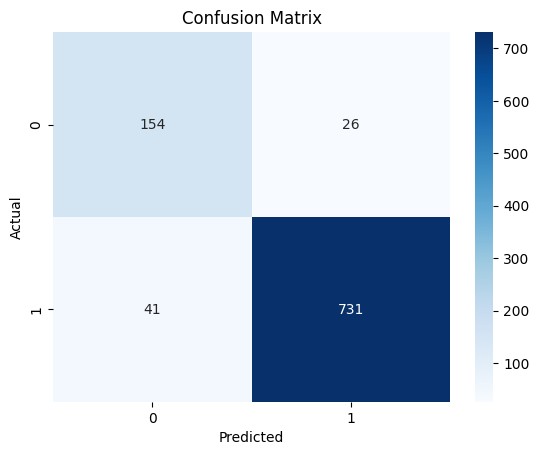

ROC Curve:


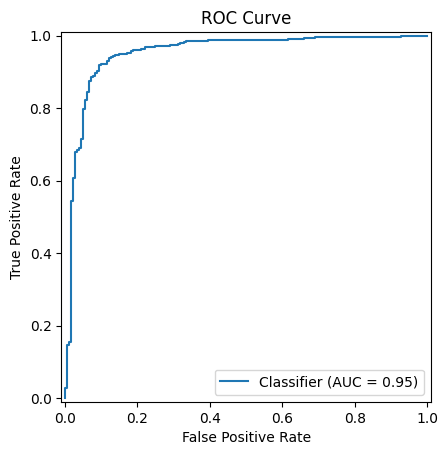

AUPRC Curve:


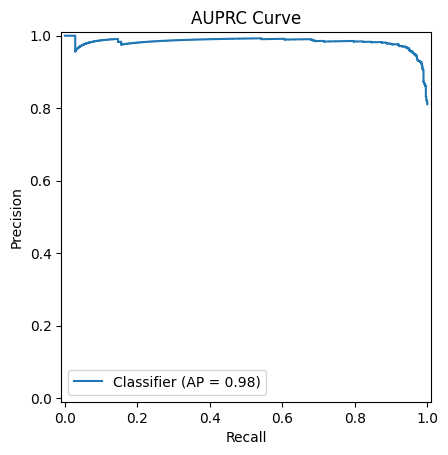

In [15]:
from sklearn.metrics import brier_score_loss, cohen_kappa_score, accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix, average_precision_score
import numpy as np

y_true = np.array(test_labels)
y_pred = np.array(test_preds)
y_prob = np.array(test_probs)

accuracy = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
mcc = matthews_corrcoef(y_true, y_pred)
auprc = average_precision_score(y_true, y_prob)
kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
npv = tn / (tn + fn) 
specificity = tn / (tn + fp)
sensitivity = recall  # same as recall
informedness = sensitivity + specificity - 1

dor = (tp * tn) / (fn * fp) if fp != 0 and fn != 0 else float('inf')

brier = brier_score_loss(y_true, y_prob)

youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold_youden = thresholds[optimal_idx]

print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Acc.: {balanced_acc:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"AUPRC: {auprc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"NPV: {npv:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print("Informedness: {:.4f}".format(informedness))
print(f"DOR: {dor:.4f}")
print(f"Brier Score: {brier:.4f}")

print("********************")
print("Confusion Matrix:")
plot_confusion_matrix(y_true, y_pred)

print("ROC Curve:")
plot_roc_curve(y_true, y_prob)

print("AUPRC Curve:")
plot_auprc_curve(y_true, y_prob)


In [ ]:
def shap_plot(final_model):
    import shap

    # Create a SHAP explainer
    #explainer = shap.TreeExplainer(final_model, X_train)
    explainer = shap.Explainer(final_model, X_train)

    # Calculate SHAP values for the test set
    shap_values = explainer.shap_values(X_test)

    # Plot summary plot
    #shap.summary_plot(shap_values, X_test, plot_type="bar")

    #emb_idx = slice(0, 1000)  # e.g., 0:1000
    #desc_idx = slice(1000, 1004)

    #print("Desc Index: " ,desc_idx)

    #explainer = shap.TreeExplainer(final_model)
    #shap_values = explainer.shap_values(X_test)  # Shape: [n_samples, n_features]

    # Overall importance
    #mean_abs_shap = np.abs(shap_values).mean(0)
    #print("Embedding total importance:", mean_abs_shap[emb_idx].sum())
    #print("Descriptors importance:", mean_abs_shap[desc_idx])

    plt.figure(figsize=(8,8))
    shap.summary_plot(shap_values, X_test)  # Clean plot!

